# Feature analysis
Emanuel de Jong (495804) - Erik Markvoort (519894)

## Imports

In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn import ensemble
from sklearn.feature_selection import SelectKBest, RFE, f_classif
from sklearn.linear_model import LogisticRegression

## Load input

In [2]:
with open(f'..{os.sep}dataset-numpy{os.sep}features_after_preprocessing.pkl', 'rb') as f:
    features = pickle.load(f)

with open(f'..{os.sep}dataset-numpy{os.sep}features_after_extraction.pkl', 'rb') as f:
    # For analysis the not yet preprocessed features are more useful.
    features_for_analysis = pickle.load(f)

## distribution analysis

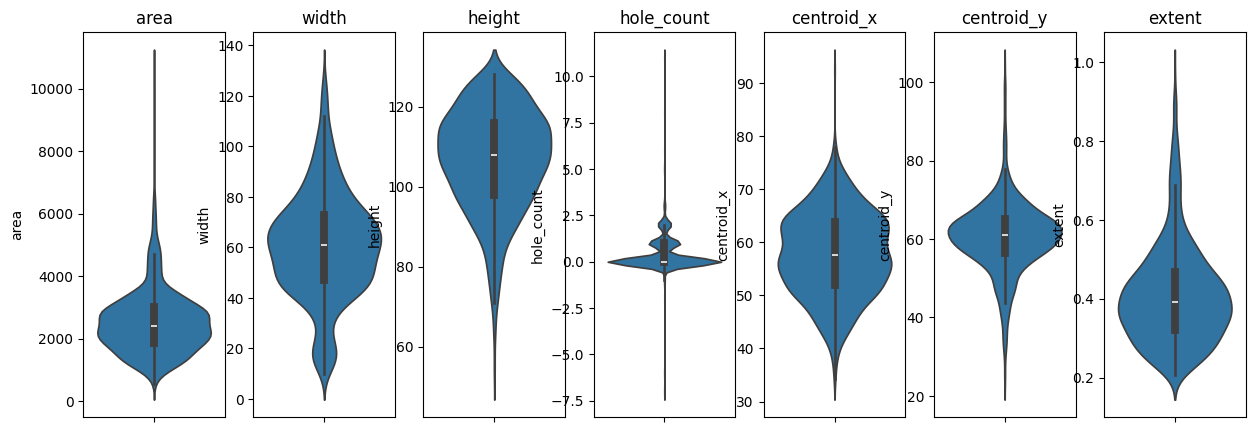

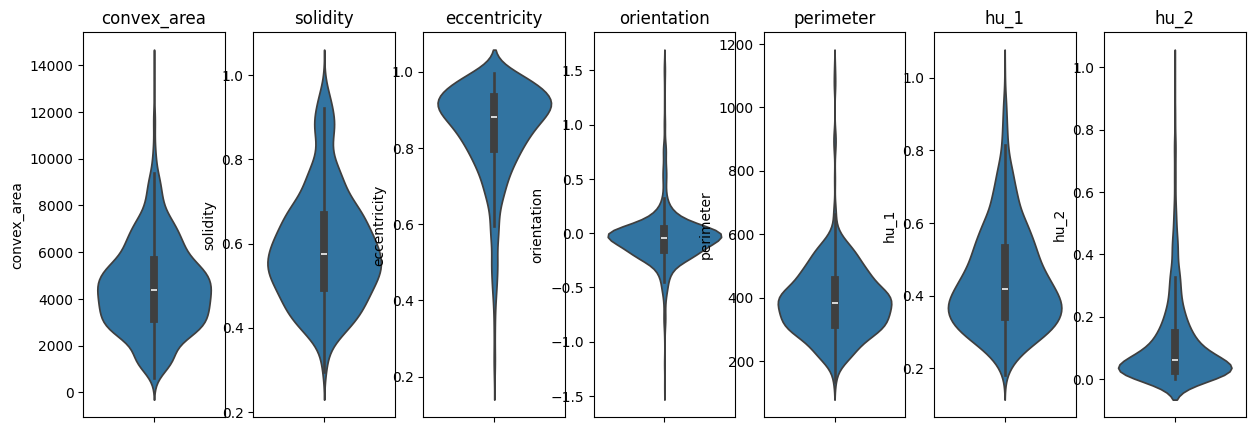

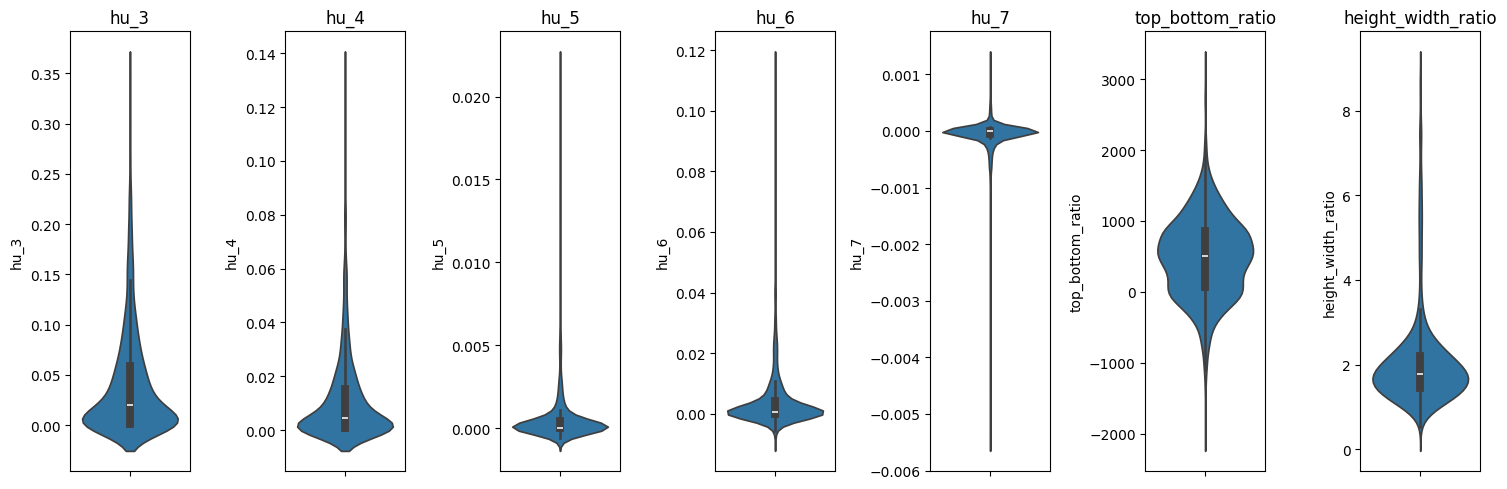

In [3]:
columns = features_for_analysis.keys()
row1 = [columns[0], columns[1], columns[2], columns[3], columns[4], columns[5], columns[6]]
row2 = [columns[7], columns[8], columns[9], columns[10], columns[11], columns[12], columns[13]]
row3 = [columns[14], columns[15], columns[16], columns[17], columns[18], columns[19], columns[20]]

fig, axes = plt.subplots(nrows=1, ncols=len(row1), figsize=(15, 5))
for i, col in enumerate(row1):
    sns.violinplot(data=features_for_analysis, y=col, ax=axes[i])
    axes[i].set_title(f'{col}')

fig, axes = plt.subplots(nrows=1, ncols=len(row2), figsize=(15, 5))
for i, col in enumerate(row2):
    sns.violinplot(data=features_for_analysis, y=col, ax=axes[i])
    axes[i].set_title(f'{col}')

fig, axes = plt.subplots(nrows=1, ncols=len(row3), figsize=(15, 5))
for i, col in enumerate(row3):
    sns.violinplot(data=features_for_analysis, y=col, ax=axes[i])
    axes[i].set_title(f'{col}')

plt.tight_layout()
plt.show()

all values: numerical, ordered
ordered numerical values are displayed in a violin plot to show whether the values are skewed left, skewed right, normal or multi-modal.

- area: skewed left. heavily concentrated around 2200. looks to have outliers.
- width: normal. not perfect normal with a raise in values on the left.
- height: skewed right. high number of values over 2 standard deviations to the right.
- hole_count: skewed left. clearly has outliers that are to be removed from negative values.
- centroid_x: normal.
- centroid_y: normal.
- extent: skewed left. outliers to the right
- convex_area: skewed left.
- solidity: skewed left.
- eccentricity: skewed right. high number of values over 2 standard deviations to the right.
- orientation: normal. outliers on both sides
- perimeter: skewed left. outliers to the right
- hu_1: skewed left. outliers to the right
- hu_2: skewed left. outliers to the right
- hu_3: skewed left. outliers to the right
- hu_4: skewed left. outliers to the right
- hu_5: skewed left. outliers to the right
- hu_6: skewed left. outliers to the right
- hu_7: skewed right. outliers on both sides
- top_bottom_ratio: normal.
- height_width_ratio: skewed left. outliers to the right

## Global

#### Variables

In [4]:
label_columns = ['label', 'label_num']

#### Functions

In [5]:
def get_features_without_labels():
    return features.drop(columns=label_columns)

def get_feature_columns():
    return get_features_without_labels().columns.tolist()

## Remove outliers
By looking for outliers per label, we can remove the troll entries automatically. 65 rows are removed because of outliers.

In [6]:
# columns_to_check = ["area"]
columns_to_check = get_feature_columns()

contamination = 0.05

print(len(features))

def remove_outliers(group):
    isolation_forest = ensemble.IsolationForest(contamination=contamination)
    outliers = isolation_forest.fit_predict(group[columns_to_check])
    return group[outliers != -1]

features = features.groupby('label_num', group_keys=False)[features.columns.tolist()].apply(remove_outliers)

# Make indexes sequential again
features.reset_index(drop=True, inplace=True)

print(len(features))

1213
1148


## Remove correlated features

#### Correlation matrix

In [7]:
def draw_correlation_matrix():
    feature_columns = get_feature_columns()
    correlation_matrix = features[feature_columns].corr()

    plt.figure(figsize=(11, 9))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        xticklabels=feature_columns,
        yticklabels=feature_columns)

    plt.show()

#### Remove high correlation features

It is not recommended to have multiple features in a dataset which are very similar. having features that are too similar would cause an unintended bias towards those values.

Features with correlation <= -0.80 or >= 0.80:
- centroid_x - top_bottom_ratio
- convex_area - area
- convex_area - width
- convex_area - perimeter
- extent - solidity
- hu_1 - hu_2
- hu_2 - height_width_ratio
- hu_4 - hu_5
- hu_4 - hu_6
- hu_5 - hu_6

Features to remove:
- **centroid_x:** I think my top_bottom_ratio shows the balance of pixels better since it's the ratio and not a coordinate position.
- **convex_area:** It solves 3 in 1 correlations.
- **extent:** I think solidity helps more with identifying irregular shapes.
- **hu_2:** hu2 has a high correlation with 2 features that can be eliminated in 1
- **hu_4:** hu 4, 5 and 6 all have a high correlation. 4 and 5 are eliminated as 6 has the lowest correlation to other features.
- **hu_5:** the same reason as hu4

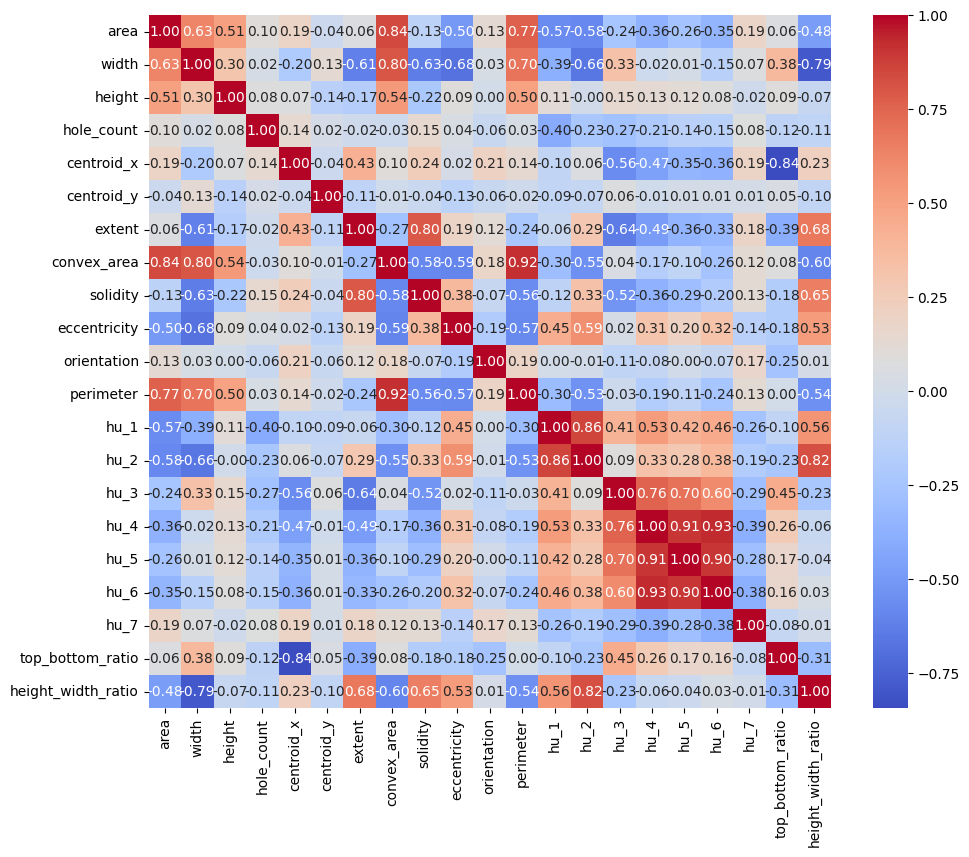

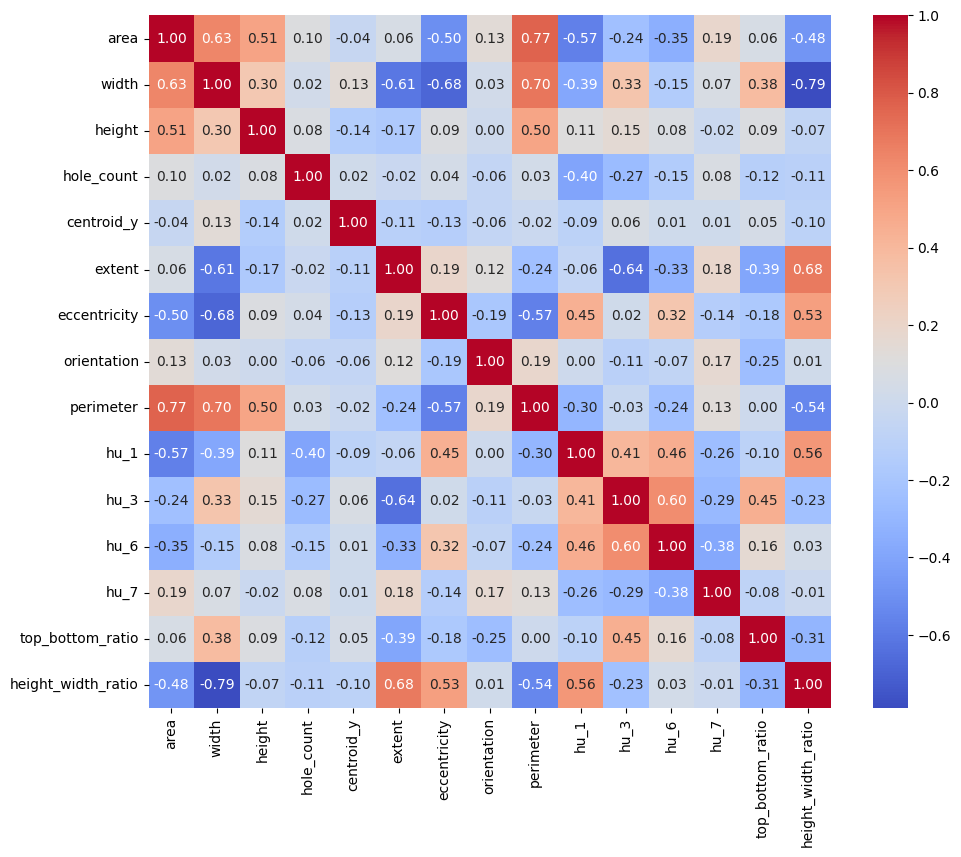

['area', 'width', 'height', 'hole_count', 'centroid_y', 'extent', 'eccentricity', 'orientation', 'perimeter', 'hu_1', 'hu_3', 'hu_6', 'hu_7', 'top_bottom_ratio', 'height_width_ratio']


In [8]:
draw_correlation_matrix()

features_with_high_correlation = ['centroid_x', 'convex_area', 'solidity', 'hu_2', 'hu_4', 'hu_5']

features = features.drop(columns=features_with_high_correlation)

draw_correlation_matrix()
print(get_feature_columns())

#### Feature selection with Select K Best

Using K-best removes all but the highest k-scoring features, using statistical analyis to find the best features.

We use f_classif because it's good for numerical interval data which most of our features are.

In [9]:
feature_count_to_keep = 8

X = get_features_without_labels()
y = features['label_num']

selector = SelectKBest(score_func=f_classif, k=feature_count_to_keep)
selector.fit_transform(X, y)

feature_columns = list(X.columns[selector.get_support()])

features = features[feature_columns + label_columns]

print(feature_columns)

['width', 'hole_count', 'extent', 'perimeter', 'hu_1', 'hu_3', 'top_bottom_ratio', 'height_width_ratio']


#### Feature selection with Recursive Feature Elimination

recursive feature elimination is used to find the optimal number of features by eliminating the features with the lowest similarity to the label one by one to find the most optimal dataset, stopping at the moment that it becomes counter-productive.

In [10]:
feature_count_to_keep = 6

X = get_features_without_labels()
y = features['label_num']

estimator = LogisticRegression()

selector = RFE(estimator, n_features_to_select=feature_count_to_keep)
selector = selector.fit(X, y)

feature_columns = list(X.columns[selector.get_support()])

features = features[feature_columns + label_columns]

print(feature_columns)

['hole_count', 'extent', 'perimeter', 'hu_1', 'hu_3', 'height_width_ratio']


## Save output

In [11]:
with open(f'..{os.sep}dataset-numpy{os.sep}features_after_analysis.pkl', 'wb') as f:
    pickle.dump(features, f)